
This project extends Borovykh et al. (2018), *Conditional Time Series Forecasting with Convolutional Neural Networks*, by applying the conditional WaveNet framework to a cross-sectional equity return prediction and portfolio construction setting. Building on the paper’s comparison between unconditional and conditional convolutional architectures, this project evaluates whether conditioning on market-level signals improves stock-level return forecasts and trading performance.

This notebook serves as the main pipeline for the Python-based backtesting framework. It integrates the core modules of the project, including data preparation, feature engineering, model construction, model training and validation, portfolio construction, out-of-sample backtesting, regime analysis, transaction cost modeling, and the Streamlit dashboard.

The workflow is designed to call the underlying Python scripts as reusable modules rather than redefining all functions directly inside the notebook. This keeps the main logic modular and organized, while allowing the notebook to act as a clear execution and experiment interface.

Specifically, this pipeline loads the prepared market and stock-level data, computes the required features and market signals, constructs the uWN, cWN, and LSTM models, runs walk-forward training and validation, generates out-of-sample predictions, builds long-short and long-only portfolios, evaluates performance metrics, and saves the final results and plots for further analysis.

After the baseline backtest is completed, the project adds three additional layers of analysis. First, the regime analysis evaluates whether strategy performance changes across different market environments, such as the pre-2020 bull market, the COVID crash, and the 2022 bear market. Second, the transaction cost modeling module uses the saved prediction files to test how portfolio performance changes under different trading costs and rebalancing frequencies. Third, the Streamlit web app provides an interactive interface for exploring the data, viewing backtest results, analyzing regimes, and running portfolio simulations without retraining the models.

The purpose of this notebook is to provide a centralized and reproducible entry point for running the full modeling, backtesting, robustness, and dashboard workflow.

## **0.** Project Structure Overview

This project is organized as a modular Python-based research and backtesting framework. The main components are separated into different folders according to their functions, including data processing, feature engineering, model implementation, backtesting, robustness analysis, transaction cost modeling, Streamlit web visualization, and result storage.

All the files should be formed as below modular python framework.

```text
IEOR4733-Final-Project/
├── data/
│   ├── raw/
│   │   ├── ohlcv.parquet             # Raw stock-level OHLCV data
│   │   ├── signals.parquet           # Raw market signal data
│   │   └── sp500_tickers.csv         # S&P 500 ticker universe
│   │
│   ├── processed/
│   │   └── features.parquet          # Processed feature dataset
│   │
│   ├── data_pipeline.py              # Data loading, cleaning, processing, and saving
│   └── features.py                   # Feature engineering for stock-level and market-level features
│
├── model/
│   ├── uWNcWN2.py                    # Main model architecture for uWN and cWN
│   ├── lorenz_test2.py               # Lorenz test and model validation
│   └── backtest_uWNcWN_LSTM2.py      # Training, validation, prediction, portfolio construction, and backtesting
│
├── robustness/
│   └── regime_analysis.py            # Regime-level performance analysis
│
├── transaction_cost/
│   ├── transactioncost.py            # Portfolio comparison with transaction cost modeling
│   ├── metrics.csv                   # Transaction-cost-adjusted performance metrics
│   ├── daily_returns.csv             # Daily strategy returns under transaction costs
│   ├── cumulative_returns.csv        # Cumulative strategy returns under transaction costs
│   ├── long_short_comparison.png     # Long-short portfolio comparison plot
│   └── long_only_comparison.png      # Long-only portfolio comparison plot
│
├── pages/
│   ├── 01_data_explorer.py           # Streamlit page for data and feature exploration
│   ├── 02_backtest_results.py        # Streamlit page for backtest result visualization
│   ├── 03_regime_analysis.py         # Streamlit page for regime analysis
│   └── 04_run_simulation.py          # Streamlit page for interactive portfolio simulation
│
├── results/
│   ├── lorenz_test/                  # Outputs from the Lorenz test
│   └── uWNcWN_LSTM2/                 # Backtesting and Regime analy sisoutputs, metrics, predictions, returns, and plots
│
├── app.py                            # Streamlit dashboard entry point
├── Main_Pipeline.ipynb               # Main notebook pipeline that coordinates all Python modules
├── README.md                         # Project documentation
├── .gitignore                        # Git ignore configuration
└── .gitattributes                    # Git attributes configuration
```

The `./data/` folder contains the data-related modules and datasets. The raw market data is stored in `./data/raw/`, while processed datasets can be stored in `./data/processed/`. The script `./data/data_pipeline.py` is used to prepare the raw data, and `./data/features.py` contains the feature engineering functions for generating stock-level features and market-level signals.

The `./model/` folder contains the core model and evaluation scripts. The file `./model/uWNcWN2.py` define the unconditional WaveNet and conditional WaveNet model structures. The backtesting logic is implemented in `./model/backtest_uWNcWN_LSTM2.py`, while `./model/lorenz_test2.py` is used for additional model evaluation through the Lorenz test.

The `./robustness/` folder contains the regime analysis script. This script uses the daily backtest return files and evaluates strategy performance across different market regimes. The regime outputs can be saved into the selected results folder and displayed in the Streamlit dashboard.

The `./transaction_cost/` folder contains the transaction cost modeling script and its outputs. This module does not retrain the neural network models. Instead, it loads the saved prediction files from the backtest results folder and reconstructs long-short and long-only portfolios under alternative transaction cost and holding period assumptions.

The `./pages/` folder and `app.py` form the Streamlit web application. The web app provides an interactive interface for data exploration, backtest visualization, regime analysis, and simulation of portfolio rules using pre-computed model predictions.

The `./results/` folder is used to store the outputs generated by the pipeline, including Lorenz test results, baseline backtest results, model prediction files, regime analysis outputs, and sensitivity analysis outputs.

This notebook serves as the main execution pipeline of the project. Instead of rewriting all functions inside the notebook, it imports the existing Python modules and coordinates the full workflow from data preparation to model testing, backtesting, robustness analysis, transaction cost modeling, and web app deployment.


## **1.** Data preparation

In this section, we prepare the data required for model training, validation, and backtesting. Since the project is organized into separate `./data/` and `./model/` folders, we first update the Python search path so that the notebook can import the corresponding modules directly.

The data preparation process is mainly implemented in `./data/data_pipeline.py`. This module is responsible for loading the raw market data, cleaning and restructuring the dataset, and saving the processed files that will be used in the later modeling pipeline.

We also import `./data/features.py`, which contains the feature engineering functions. These functions are used to construct stock-level features and market-level signals, which serve as the input variables for the uWN, cWN, and LSTM models.

After importing the required modules, we run `data_pipeline.run_pipeline()` to execute the full data preparation process. This step ensures that the raw data is transformed into the required format before entering the model construction, validation, and backtesting stages.


In [6]:
import sys
import importlib

sys.path.append("./model")
sys.path.append("./data")

from data import features
from data import data_pipeline


In [8]:
data_pipeline.run_pipeline()


  Phase 1 - S&P 500 Data Pipeline (extended features)

╔══════════════════════════════════════════════════════╗
║          Feature Library Summary                     ║
╠══════════════════════════════════════════════════════╣
║  A Returns Momentum               9 features  ║
║  B Trend                          8 features  ║
║  C Volatility                     5 features  ║
║  D Oscillators                    7 features  ║
║  E Volume Liquidity               6 features  ║
║  F Price Structure                5 features  ║
║  G Market Signals                 8 features  ║
╠══════════════════════════════════════════════════════╣
║  Total (per-stock)               40 features  ║
║  Total (incl. market signals)    48 features  ║
╚══════════════════════════════════════════════════════╝

Step 1: Tickers
  [cache] Tickers loaded from disk.

Step 2: OHLCV
  [cache] OHLCV loaded from disk.

Step 3: Market signals
  [cache] Signals loaded from disk.

Step 4: Stock features
  Computing features fo

## **2.** Reproduce the Model

In this part, we implement the unconditional WaveNet model, uWN, and the conditional WaveNet model, cWN, following the structure described in the paper. The corresponding model code is stored in `./model/uWNcWN2.py`.

Following the paper, we also conduct the Lorenz test to evaluate the model. The implementation of this test is stored in `./model/lorenz_test2.py`.

Here, we import the required model and testing modules, reload them to make sure the latest code is used, and then present the results of the Lorenz test.

In [5]:
from model import uWNcWN2
from model import lorenz_test2

importlib.reload(uWNcWN2)
importlib.reload(lorenz_test2)

<module 'model.lorenz_test2' from 'd:\\Columbia\\AlgoTrading\\FinalProject\\IEOR4733-Final-Project\\model\\lorenz_test2.py'>

Using device: cuda
Figure save directory: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test

Running experiment for X...
X: RMSE uWN (std) = 0.018441, RMSE cWN (std) = 0.014334, RMSE uWN (orig) = 0.127202, RMSE cWN (orig) = 0.098871


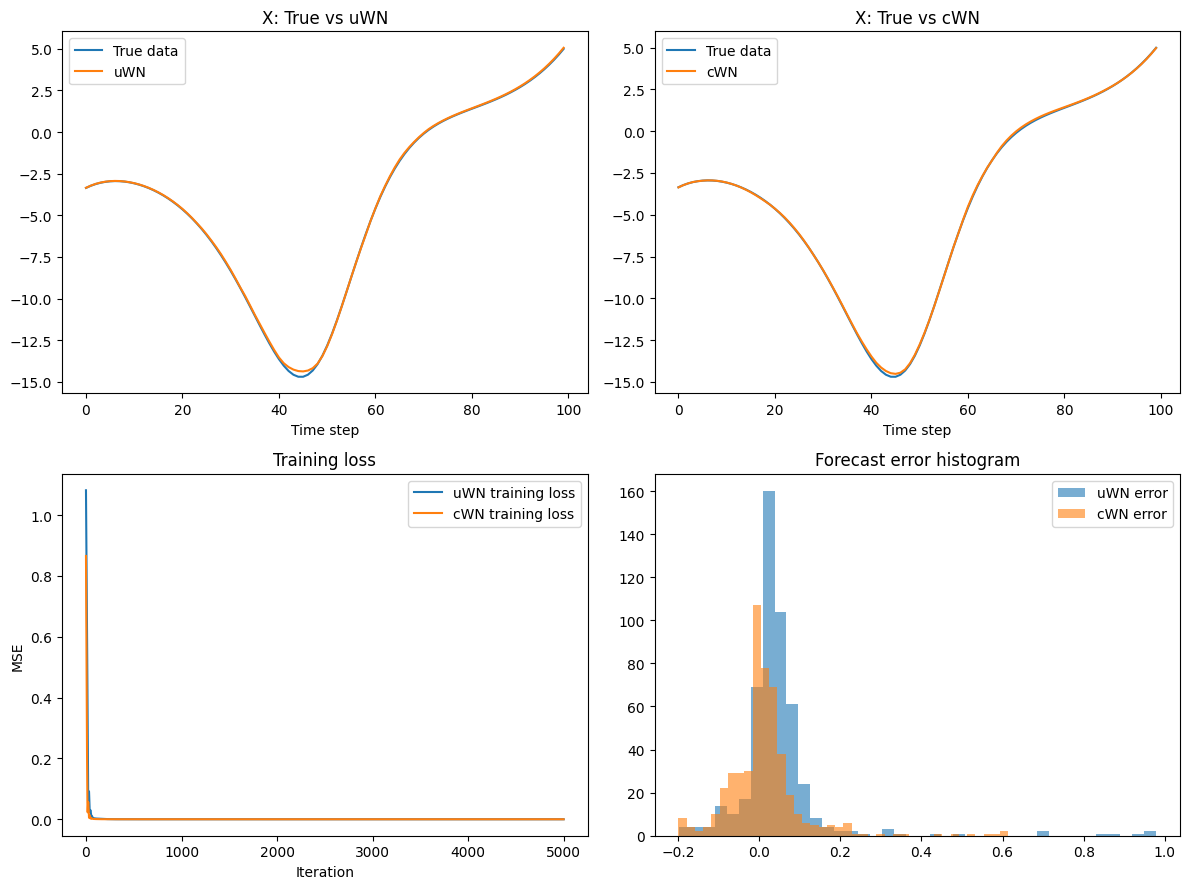

Saved figure: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\lorenz_X.png

Running experiment for Y...
Y: RMSE uWN (std) = 0.022610, RMSE cWN (std) = 0.032951, RMSE uWN (orig) = 0.184382, RMSE cWN (orig) = 0.268704


<Figure size 640x480 with 0 Axes>

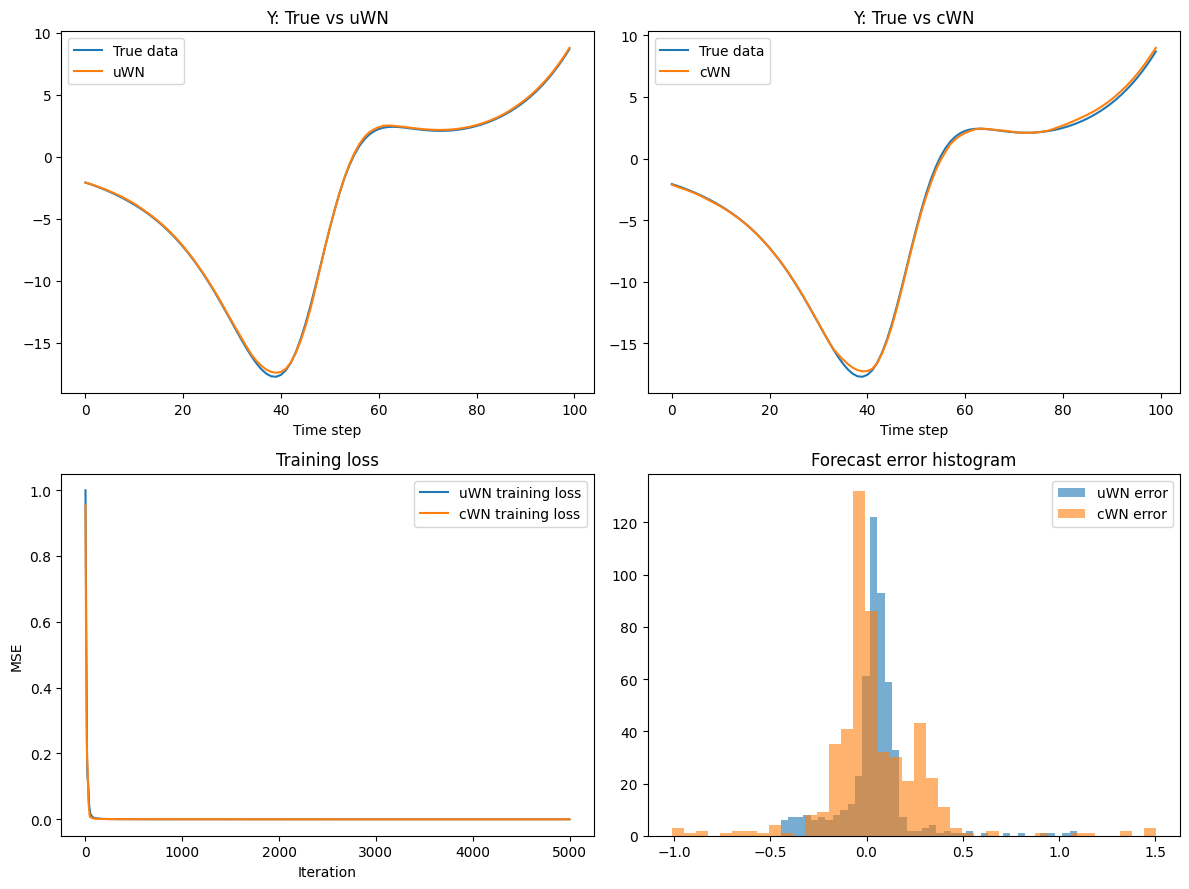

Saved figure: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\lorenz_Y.png

Running experiment for Z...
Z: RMSE uWN (std) = 0.006412, RMSE cWN (std) = 0.030777, RMSE uWN (orig) = 0.059576, RMSE cWN (orig) = 0.285978


<Figure size 640x480 with 0 Axes>

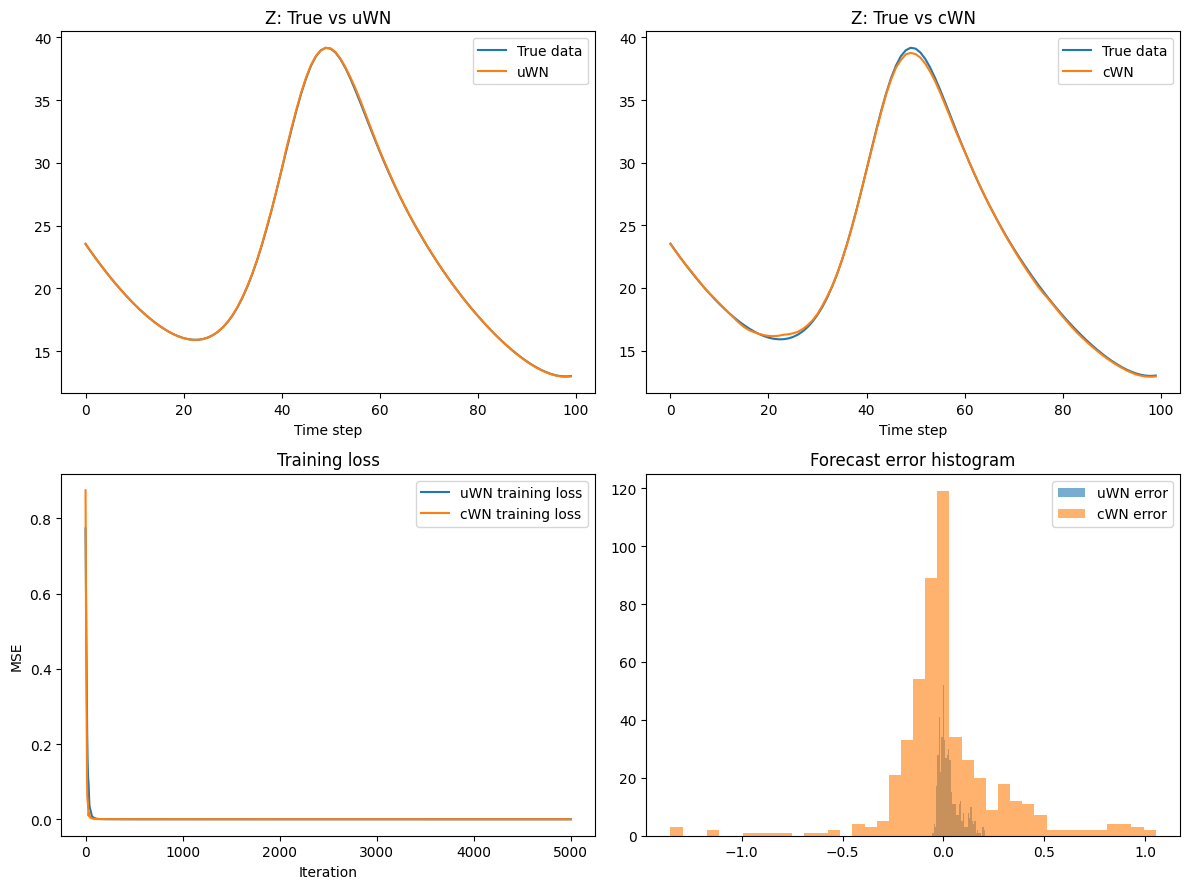

Saved figure: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\lorenz_Z.png

Saved RMSE summary to: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\rmse_summary.csv

===== RMSE Summary =====
Coordinate  RMSE_uWN_std  RMSE_cWN_std  RMSE_uWN_orig  RMSE_cWN_orig
         X      0.018441      0.014334       0.127202       0.098871
         Y      0.022610      0.032951       0.184382       0.268704
         Z      0.006412      0.030777       0.059576       0.285978


<Figure size 640x480 with 0 Axes>

In [6]:
lorenz_test2.lorenz_test()

The Lorenz test results provide an additional validation of the reproduced uWN and cWN model structures. The table reports the RMSE values for three coordinates, `x`, `y`, and `z`, under both the standardized setting and the original scale.

Overall, the RMSE values remain relatively small, especially for the standardized outputs. For the `x` coordinate, cWN achieves a lower standardized RMSE than uWN, with values of 0.014334 and 0.018441 respectively. This indicates that the conditional WaveNet is able to improve the fitting accuracy when market condition information is incorporated. For the original-scale results, cWN also improves upon uWN for the `x` coordinate, reducing the RMSE from 0.127202 to 0.098871.

Although cWN does not dominate uWN for every coordinate, the results are generally consistent with the expected behavior discussed in the paper. The conditional model can capture additional information through the conditioning variables, while the unconditional model still provides a stable benchmark. The Lorenz test therefore confirms that the reproduced model is able to generate reasonable and comparable outputs.

Based on these results, the model implementation is considered successful. The uWN and cWN structures have been correctly constructed and can be further integrated into the full training, validation, portfolio construction, and backtesting pipeline.

## **3.** Backtesting Pipeline

In this section, we run the main backtesting pipeline for the uWN, cWN, and LSTM models. The corresponding implementation is provided in `./model/backtest_uWNcWN_LSTM2.py`.

This module integrates the major components of the empirical experiment, including feature loading, sample construction, rolling-window training, validation, prediction generation, portfolio construction, performance evaluation, and result visualization. The notebook imports and reloads the backtesting module to ensure that the latest version of the Python script is used.

The backtest is executed by calling `backtest_uWNcWN_LSTM2.backtest()`. The argument `--results_dir` is specified so that all generated outputs are saved into `./results/uWNcWN_LSTM2/`. These outputs include performance metrics, daily returns, cumulative returns, model predictions, and backtest plots.

This section serves as the final execution stage of the pipeline. After the data has been prepared and the model structures have been reproduced and validated, the backtesting module evaluates the out-of-sample performance of the models and compares their portfolio-level results.

In [7]:
from model import backtest_uWNcWN_LSTM2

importlib.reload(backtest_uWNcWN_LSTM2)

<module 'model.backtest_uWNcWN_LSTM2' from 'd:\\Columbia\\AlgoTrading\\FinalProject\\IEOR4733-Final-Project\\model\\backtest_uWNcWN_LSTM2.py'>

In [8]:
backtest_uWNcWN_LSTM2.backtest([
    "--results_dir", "results/uWNcWN_LSTM2"
])

Using device: cuda

[1/4] Loading OHLCV …
[2/4] Loading market signals …
[3/4] Computing stock features …
  Computing features for 503 tickers …
    … 0/503
    … 100/503
    … 200/503
    … 300/503
    … 400/503
    … 500/503
[4/4] Computing market signals …
Merging & cleaning …
  Dataset: 1,776,305 rows | 3770 dates | 501 tickers

── Fold 1  test: 2013-07-08 → 2013-10-03 ──
  Train: 205,190 samples | Val: 42,787 samples
  X_tr_n finite: True | max abs: 255.6279
  X_vl_n finite: True | max abs: 76.5551
  uWN  – trained 21 epochs | best val loss: 0.665826
  cWN  – trained 21 epochs | best val loss: 0.655025
  LSTM – trained 21 epochs | best val loss: 0.628354

── Fold 2  test: 2013-10-04 → 2014-01-03 ──
  Train: 206,172 samples | Val: 43,059 samples
  X_tr_n finite: True | max abs: 161.6718
  X_vl_n finite: True | max abs: 193.0156
  uWN  – trained 21 epochs | best val loss: 0.553998
  cWN  – trained 21 epochs | best val loss: 0.564623
  LSTM – trained 22 epochs | best val loss: 0.5460

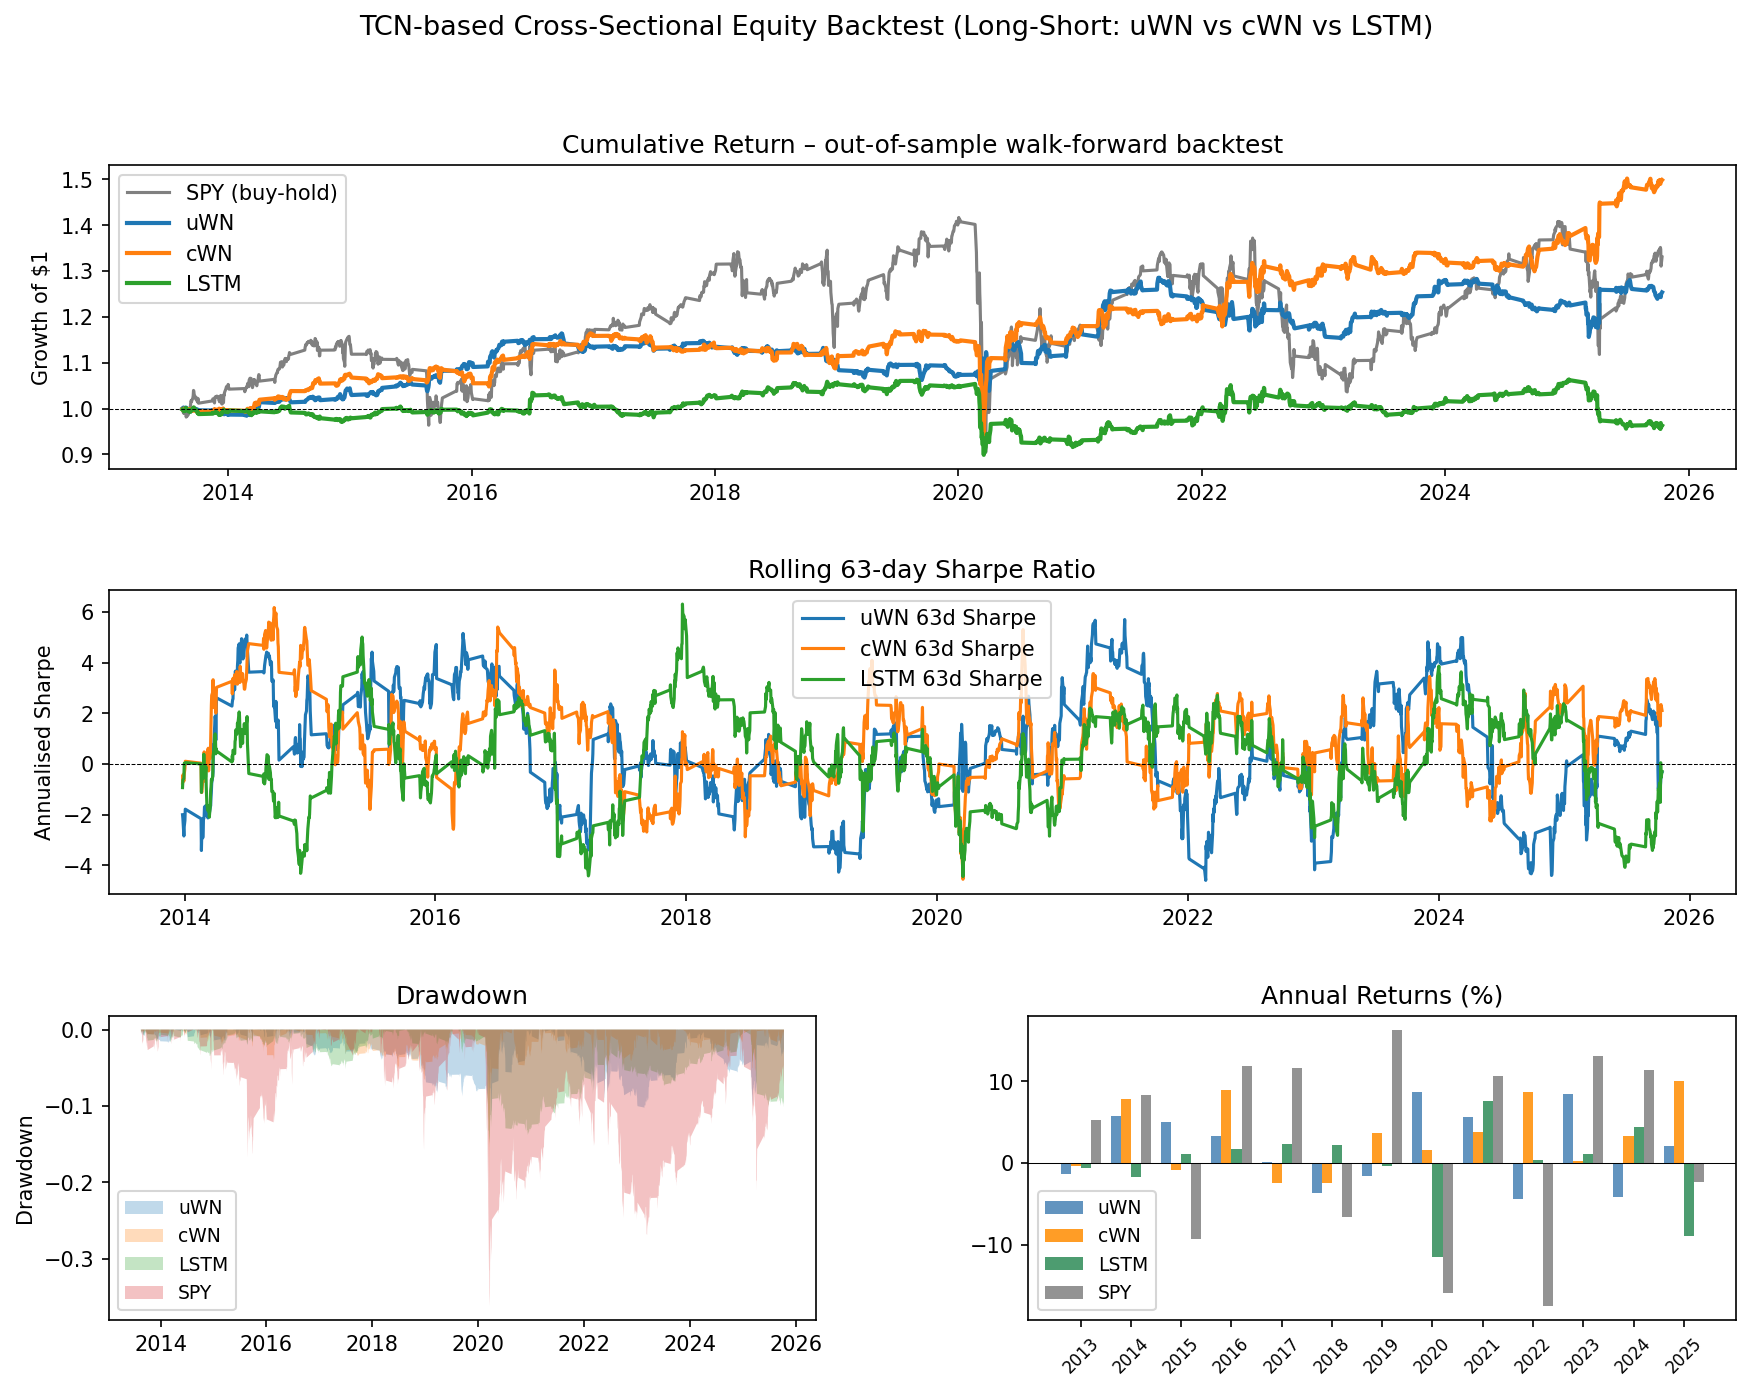

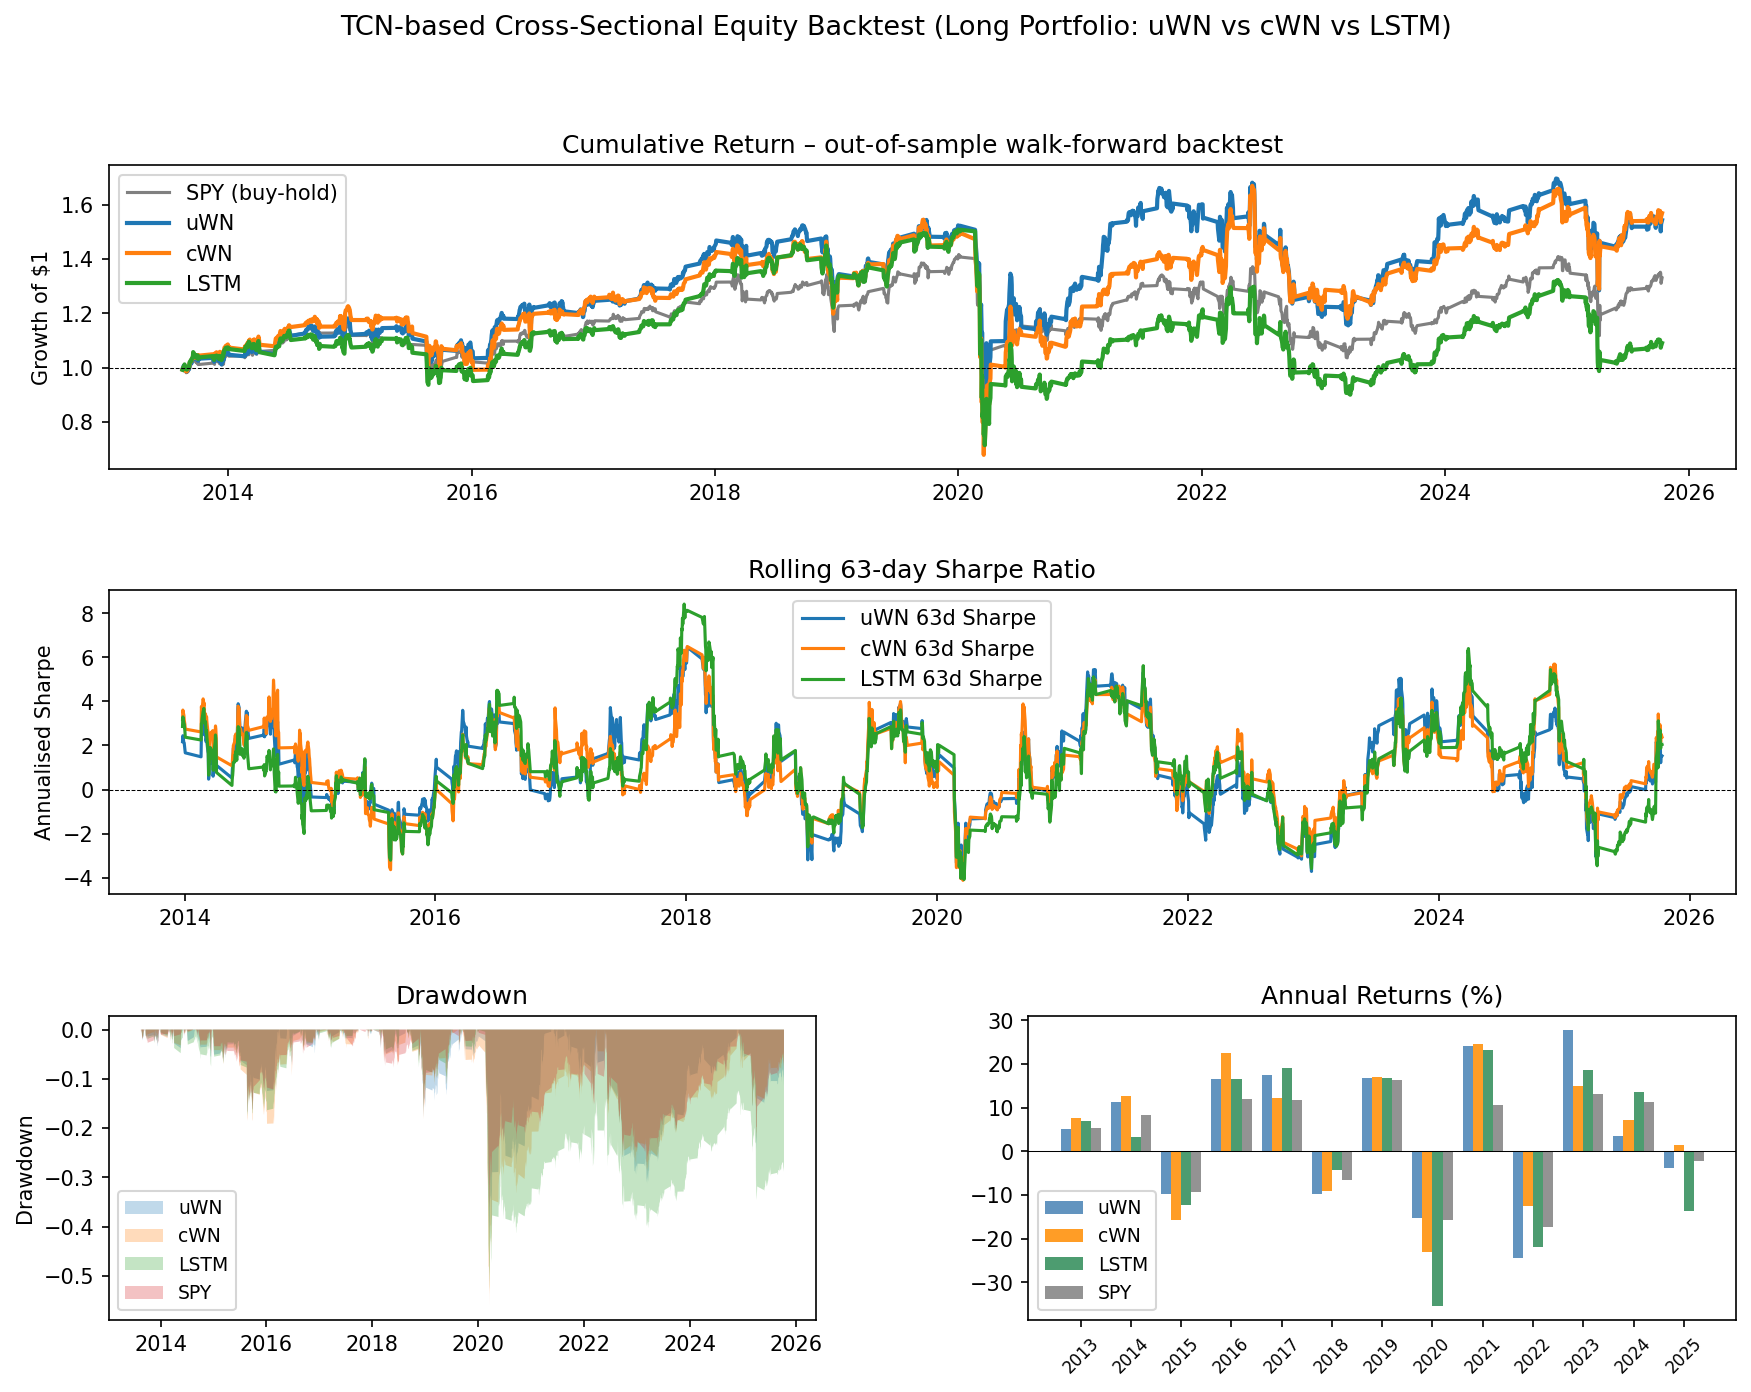

In [4]:
from IPython.display import Image, display

display(Image(filename="results/uWNcWN_LSTM2/backtest_ls_with_lstm.png"))
display(Image(filename="results/uWNcWN_LSTM2/backtest_long_with_lstm.png"))

The backtesting results show clear differences across the three models under both long-short and long-only portfolio settings.

From the long-short cumulative return plot, cWN achieves the strongest overall performance over the full out-of-sample period. Its equity curve grows more steadily after 2020 and ends at the highest level among the three models, reaching close to 1.5 times the initial capital. uWN also generates positive cumulative returns, but its final performance is lower than cWN and its growth becomes flatter after 2022. In contrast, the LSTM strategy remains close to or below the initial capital for most of the sample period, suggesting weaker predictive power in this cross-sectional setting.

The rolling 63-day Sharpe ratio further supports this observation. Both uWN and cWN experience periods of positive and negative risk-adjusted performance, but cWN shows stronger positive Sharpe episodes, especially near the end of the sample. The drawdown plot indicates that all strategies experience losses during stressed periods, particularly around 2020, but the model-based long-short strategies generally have smaller drawdowns than SPY. The annual return chart also shows that cWN produces more consistently positive yearly returns than uWN and LSTM in several years.

The long-only portfolio results provide an additional perspective. In the cumulative return plot, all three models are more closely related to the market trend because the portfolios only take long positions. Before 2020, uWN and cWN both achieve strong growth, with uWN slightly leading in some periods. However, after the market disruption around 2020, cWN recovers more effectively and remains competitive through the later sample period. LSTM also improves under the long-only setting compared with its long-short result, but it still does not consistently outperform uWN or cWN. The rolling Sharpe ratios of the long-only strategies move closely together, showing that their risk-adjusted performance is more affected by common market conditions. The drawdown plot also shows larger downside exposure than the long-short case, especially during market stress, which is expected because the long-only portfolios cannot hedge by taking short positions.

The summary table provides numerical support for these graphical results. For the long-short portfolios, cWN achieves the highest cumulative return of 49.9%, the highest annual return of 6.3%, and the highest Sharpe ratio of 0.726. uWN also performs positively, with a cumulative return of 25.4% and a Sharpe ratio of 0.476. By comparison, LSTM has a negative cumulative return of -3.7% and a slightly negative Sharpe ratio of -0.085, indicating that it fails to generate stable out-of-sample alpha in the long-short setting.

For the long-only portfolios, all three models generate positive cumulative returns. cWN again achieves the highest cumulative return at 56.9%, slightly outperforming uWN at 54.4%. However, the long-only strategies also have much higher annualized volatility and larger maximum drawdowns than their long-short versions. This suggests that the long-only portfolios benefit from market exposure but are also more vulnerable to broad market downturns. Overall, the results suggest that the conditional WaveNet model benefits from incorporating market condition information and provides the best overall out-of-sample performance among the tested models, especially in the long-short portfolio setting.

## **4.** Regime Analysis

After the main backtest is completed, I added a regime analysis module to examine whether the model-based strategies perform differently across market environments. The implementation is stored in `./robustness/regime_analysis.py`, and the Streamlit visualization version is stored in `./pages/03_regime_analysis.py`.

The regime analysis uses the daily return file generated by the main backtest `./results/uWNcWN_LSTM2/daily_returns.csv`. It then evaluates the uWN, cWN, LSTM, and SPY benchmark returns over several representative periods, including the bull market before 2020, the COVID crash, and the 2022 bear market. For each regime, the script computes performance statistics such as annualized return, annualized volatility, Sharpe ratio, and maximum drawdown.

In [1]:
# Run the regime analysis module after the main backtest has generated daily_returns.csv.
# This command saves regime-level tables and plots into the selected results folder.

!python robustness/regime_analysis.py --results_dir results/uWNcWN_LSTM2



  REGIME PERFORMANCE ANALYSIS

──────────────────────────────────────────────────────────────────────
  Bull Market (2010–2019)  [2013-08-16 → 2019-12-31]  (880 trading days)
──────────────────────────────────────────────────────────────────────
  Strategy              AnnRet%  AnnVol%   Sharpe   MaxDD%   Calmar    Hit%
  -------------------------------------------------------------------------
  uWN L/S                   2.2      4.0    0.538     -8.8     0.25    51.7
  cWN L/S                   4.0      4.8    0.849     -6.6     0.61    52.4
  LSTM L/S                  1.4      3.7    0.375     -5.2     0.27    49.4
  uWN Long                 13.1     14.6    0.902    -17.8     0.74    56.1
  cWN Long                 12.7     15.3    0.830    -19.1     0.66    55.7
  LSTM Long                12.8     14.3    0.898    -17.6     0.73    56.1
  SPY B&H                  10.6     12.9    0.816    -16.8     0.63    53.9

────────────────────────────────────────────────────────────────────

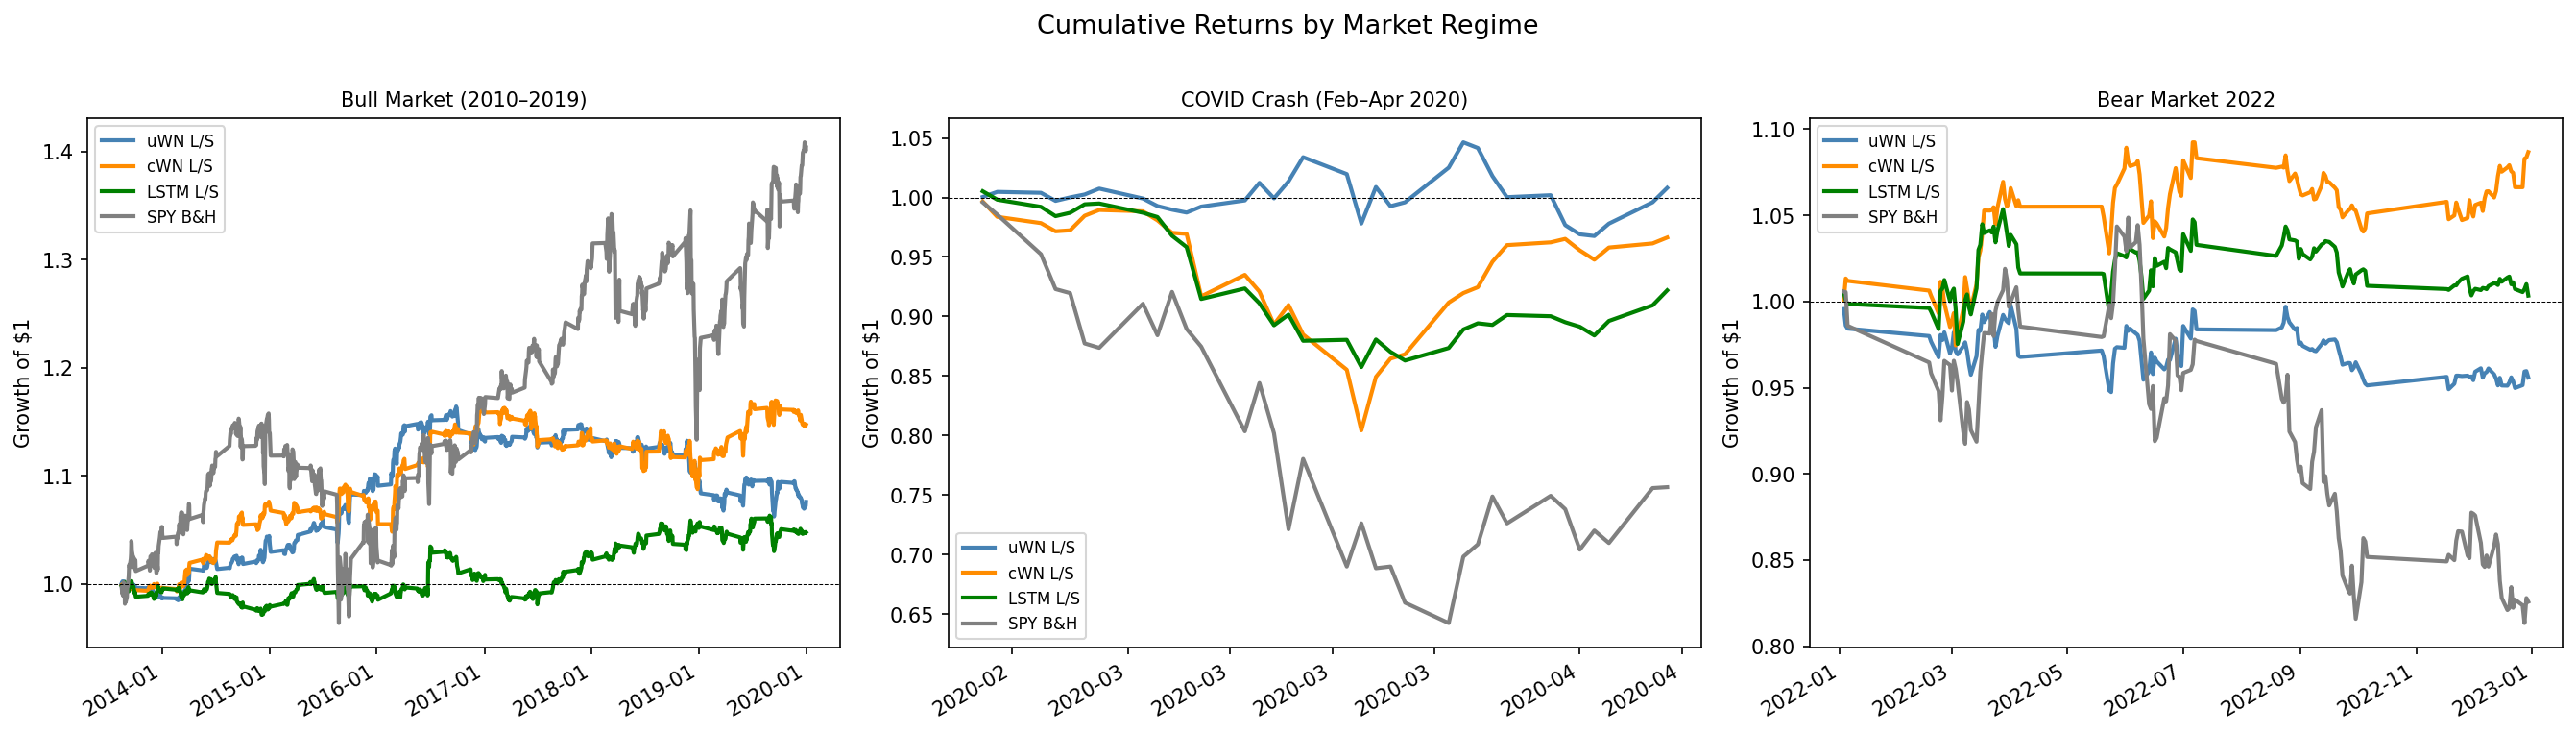

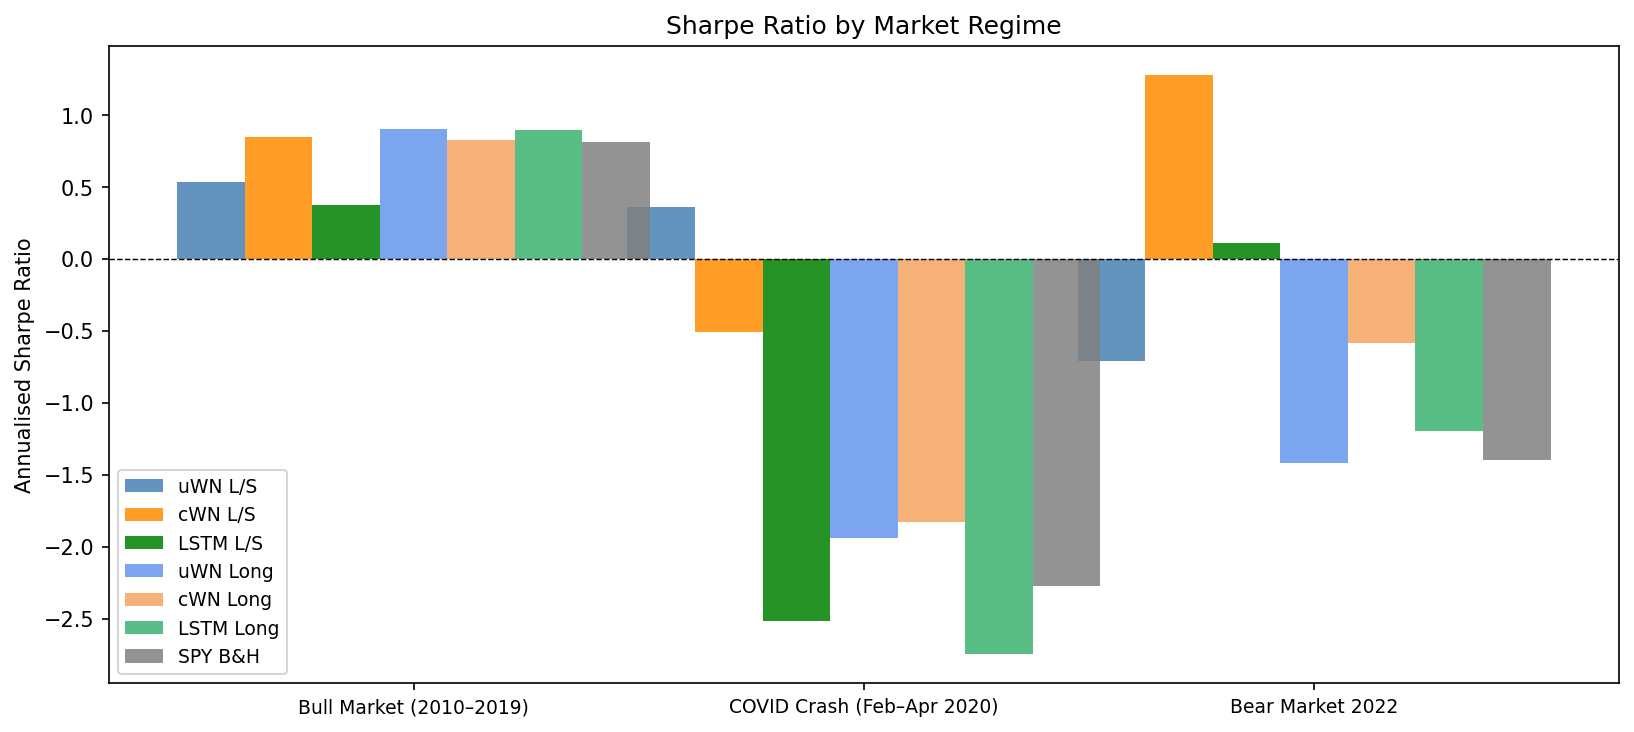

In [9]:
display(Image(filename="results/uWNcWN_LSTM2/regime_cumulative.png"))
display(Image(filename="results/uWNcWN_LSTM2/regime_sharpe.png"))


During the bull market period, all strategies generated relatively stable performance. The long-only portfolios performed especially well because they benefited from the upward market trend. The uWN Long, cWN Long, and LSTM Long portfolios all achieved Sharpe ratios close to or above the SPY benchmark, with uWN Long producing the highest Sharpe ratio of 0.902. Among the long-short strategies, cWN performed the best, with an annualized return of 4.0% and a Sharpe ratio of 0.849. This suggests that conditioning on market-level signals improved the model’s ability to form relative-value portfolios during normal expansionary market conditions.

The COVID crash period shows a very different pattern. The long-only strategies suffered large losses because they remained exposed to the broad market decline. SPY also experienced a large negative annualized return and a Sharpe ratio of -2.276. In contrast, the uWN long-short strategy was much more resilient, producing a positive Sharpe ratio of 0.362 and a much smaller maximum drawdown of -7.5%. This indicates that the market-neutral long-short construction helped reduce downside exposure during the crash. However, cWN and LSTM long-short portfolios performed worse in this period, suggesting that the additional model structure did not necessarily improve robustness during extreme market stress.

In the 2022 bear market, the advantage of the cWN long-short strategy becomes much clearer. While SPY and all long-only strategies had negative annualized returns, cWN L/S achieved a positive annualized return of 16.3%, a Sharpe ratio of 1.279, and the strongest Calmar ratio of 3.39. This result suggests that the conditional model was especially effective in a prolonged bear-market environment, where market signals may have contained useful information for ranking stocks. By contrast, uWN L/S had a negative Sharpe ratio of -0.708, while LSTM L/S was only slightly positive with a Sharpe ratio of 0.112.

Overall, the regime analysis shows that no single model dominates in every environment, but the cWN long-short strategy appears to be the most robust across regimes. It performs strongly in the bull market, delivers the best performance in the 2022 bear market, and remains competitive in risk-adjusted terms across the full set of regimes. The results also highlight the importance of portfolio construction: long-only strategies perform well in rising markets but become highly exposed during downturns, while long-short strategies can reduce market exposure and potentially generate returns from cross-sectional stock ranking. This supports the main conclusion that conditional forecasting signals are most valuable when they are combined with a portfolio construction method that controls market exposure.

The regime analysis outputs can then be viewed directly in the Streamlit dashboard through the `Regime Analysis` page. This page loads the same `daily_returns.csv` file, computes regime-specific Sharpe ratios, and visualizes cumulative returns across the selected market periods. The purpose is to compare the models not only by full-sample performance, but also by how they behave in normal, crisis, and bear-market conditions.


## **5.** Transaction Cost Modeling and Portfolio Sensitivity

I also added a separate transaction cost modeling module. The script is stored in `./transaction_cost/transactioncost.py`. Unlike the main backtest script, this module does not retrain uWN, cWN, or LSTM. Instead, it assumes that the prediction files have already been generated by the main backtest and saved in the results folder.

The expected input files are:

```text
results/uWNcWN_LSTM2/predictions_uWN.csv
results/uWNcWN_LSTM2/predictions_cWN.csv
results/uWNcWN_LSTM2/predictions_LSTM.csv
```

The module loads these saved prediction files, ranks stocks by predicted return, forms long-short and long-only portfolios, and deducts transaction costs based on turnover. The transaction cost is modeled as a one-way cost in basis points and is charged only on rebalance days. The module also allows the holding period to be changed, so the strategy can be tested under daily, weekly, biweekly, or monthly rebalancing assumptions.

This extension is important because the original backtest performance can be overstated if trading frictions are ignored. Since cross-sectional strategies may require frequent rebalancing, turnover and transaction costs can meaningfully reduce realized performance. The transaction cost module therefore provides a more realistic evaluation of whether the model predictions remain useful after implementation costs.


In [14]:
# Run transaction cost modeling using the saved prediction files from the main backtest.
# The results are saved into the transaction_cost folder.

!python transaction_costs/transactioncost.py \
    --pred_dir results/uWNcWN_LSTM2 \
    --results_dir transaction_cost \
    --cost_bps 10 \
    --holding 1 \
    --top_frac 0.20 \
    --bot_frac 0.20


Loaded uWN: 796,267 rows from results/uWNcWN_LSTM2/predictions_uWN.csv
Loaded cWN: 796,267 rows from results/uWNcWN_LSTM2/predictions_cWN.csv
Loaded LSTM: 796,267 rows from results/uWNcWN_LSTM2/predictions_LSTM.csv
Formed portfolio for uWN: 1,666 days
Formed portfolio for cWN: 1,666 days
Formed portfolio for LSTM: 1,666 days

PORTFOLIO PERFORMANCE COMPARISON
           name  cum_return_pct  ann_return_pct  ann_vol_pct  sharpe  max_drawdown_pct  hit_rate_pct  n_days
    uWN L/S net          -83.19          -23.64         7.33  -3.224            -83.28         31.15    1666
  uWN L/S gross           25.37            3.48         7.31   0.476            -10.78         51.38    1666
   uWN Long net          -78.45          -20.72        24.24  -0.855            -80.91         49.04    1666
 uWN Long gross           54.37            6.79        24.21   0.280            -43.94         54.80    1666
    cWN L/S net          -79.44          -21.28         8.72  -2.440            -80.16        

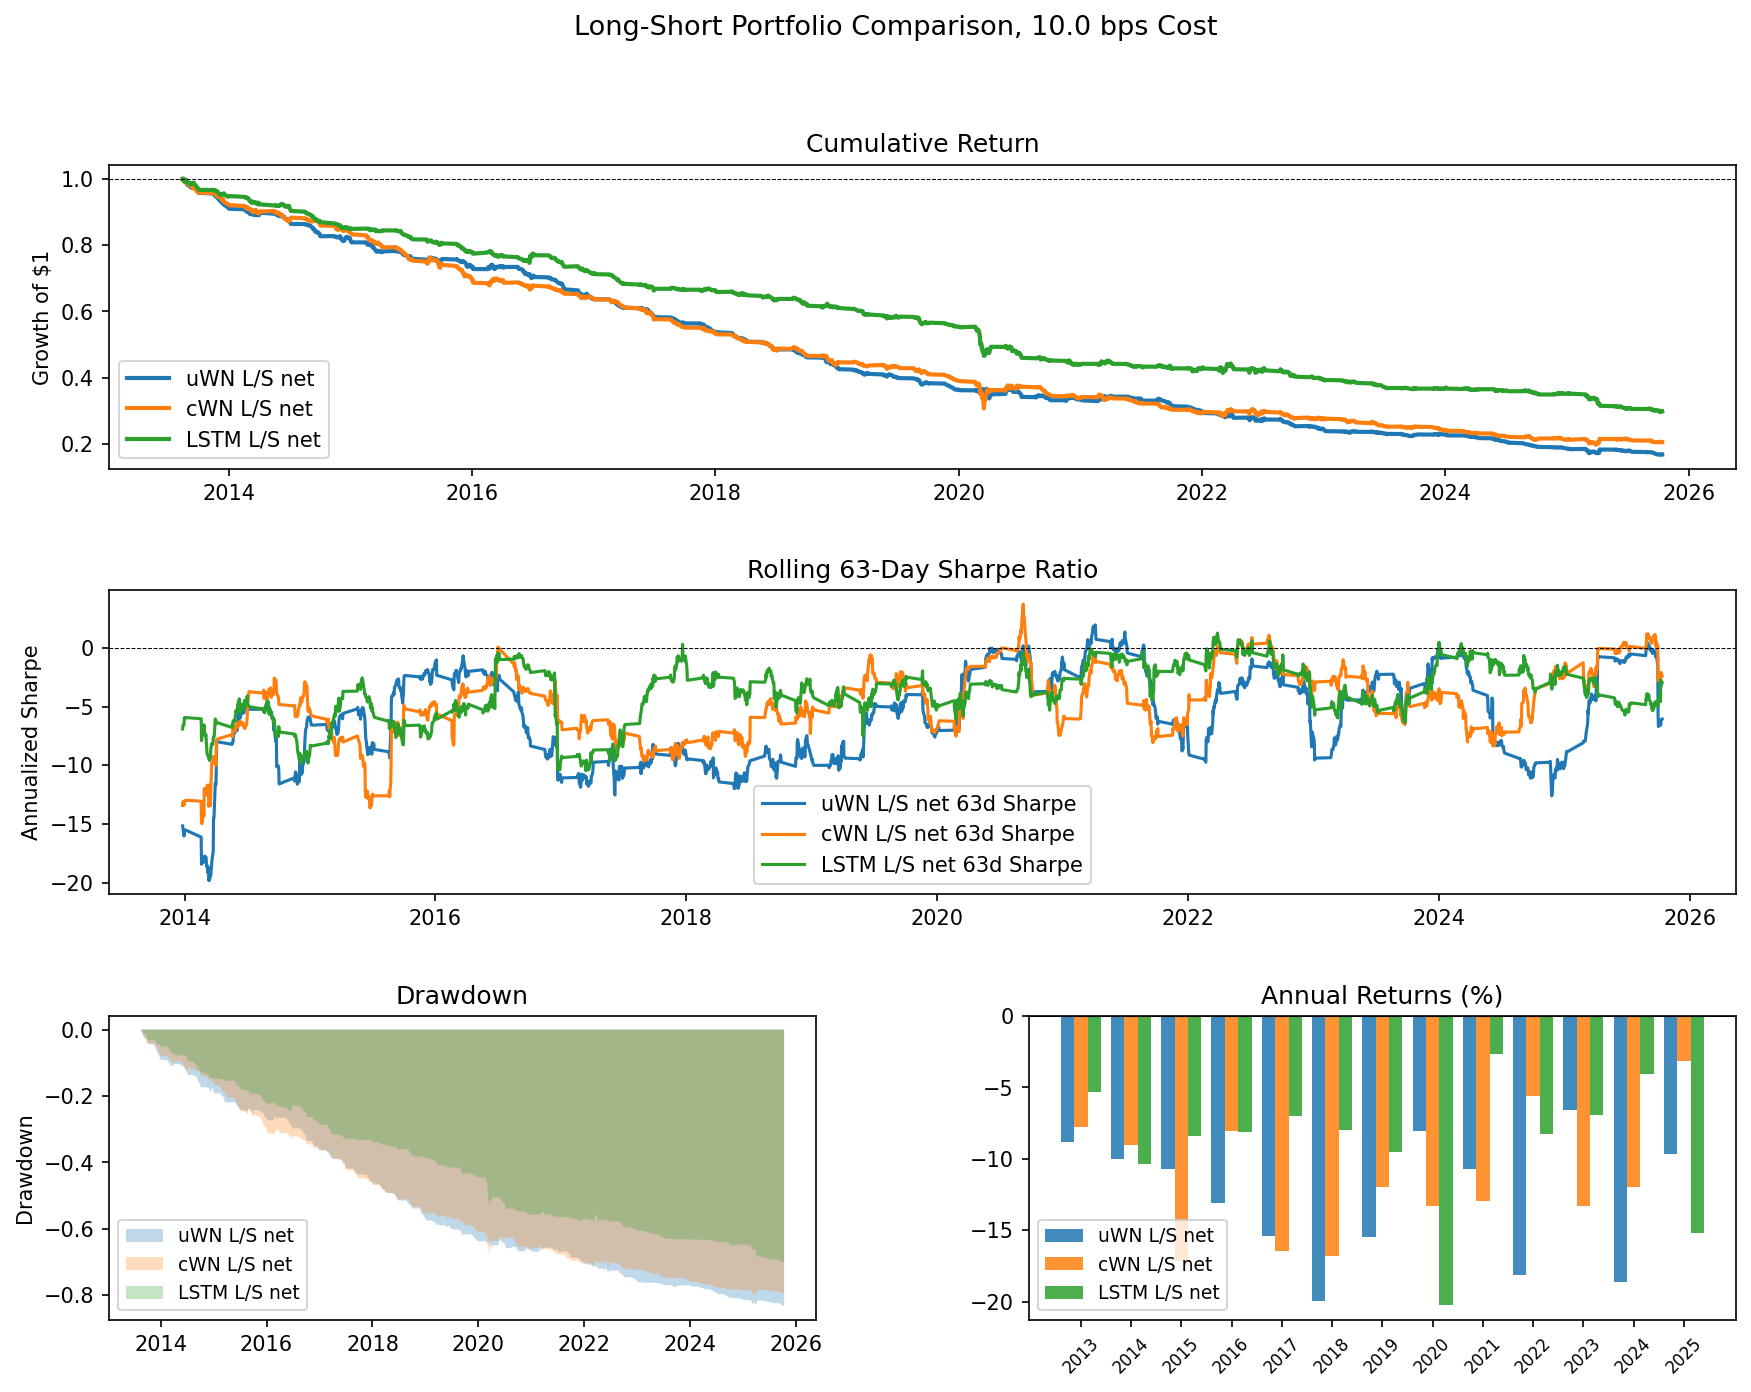

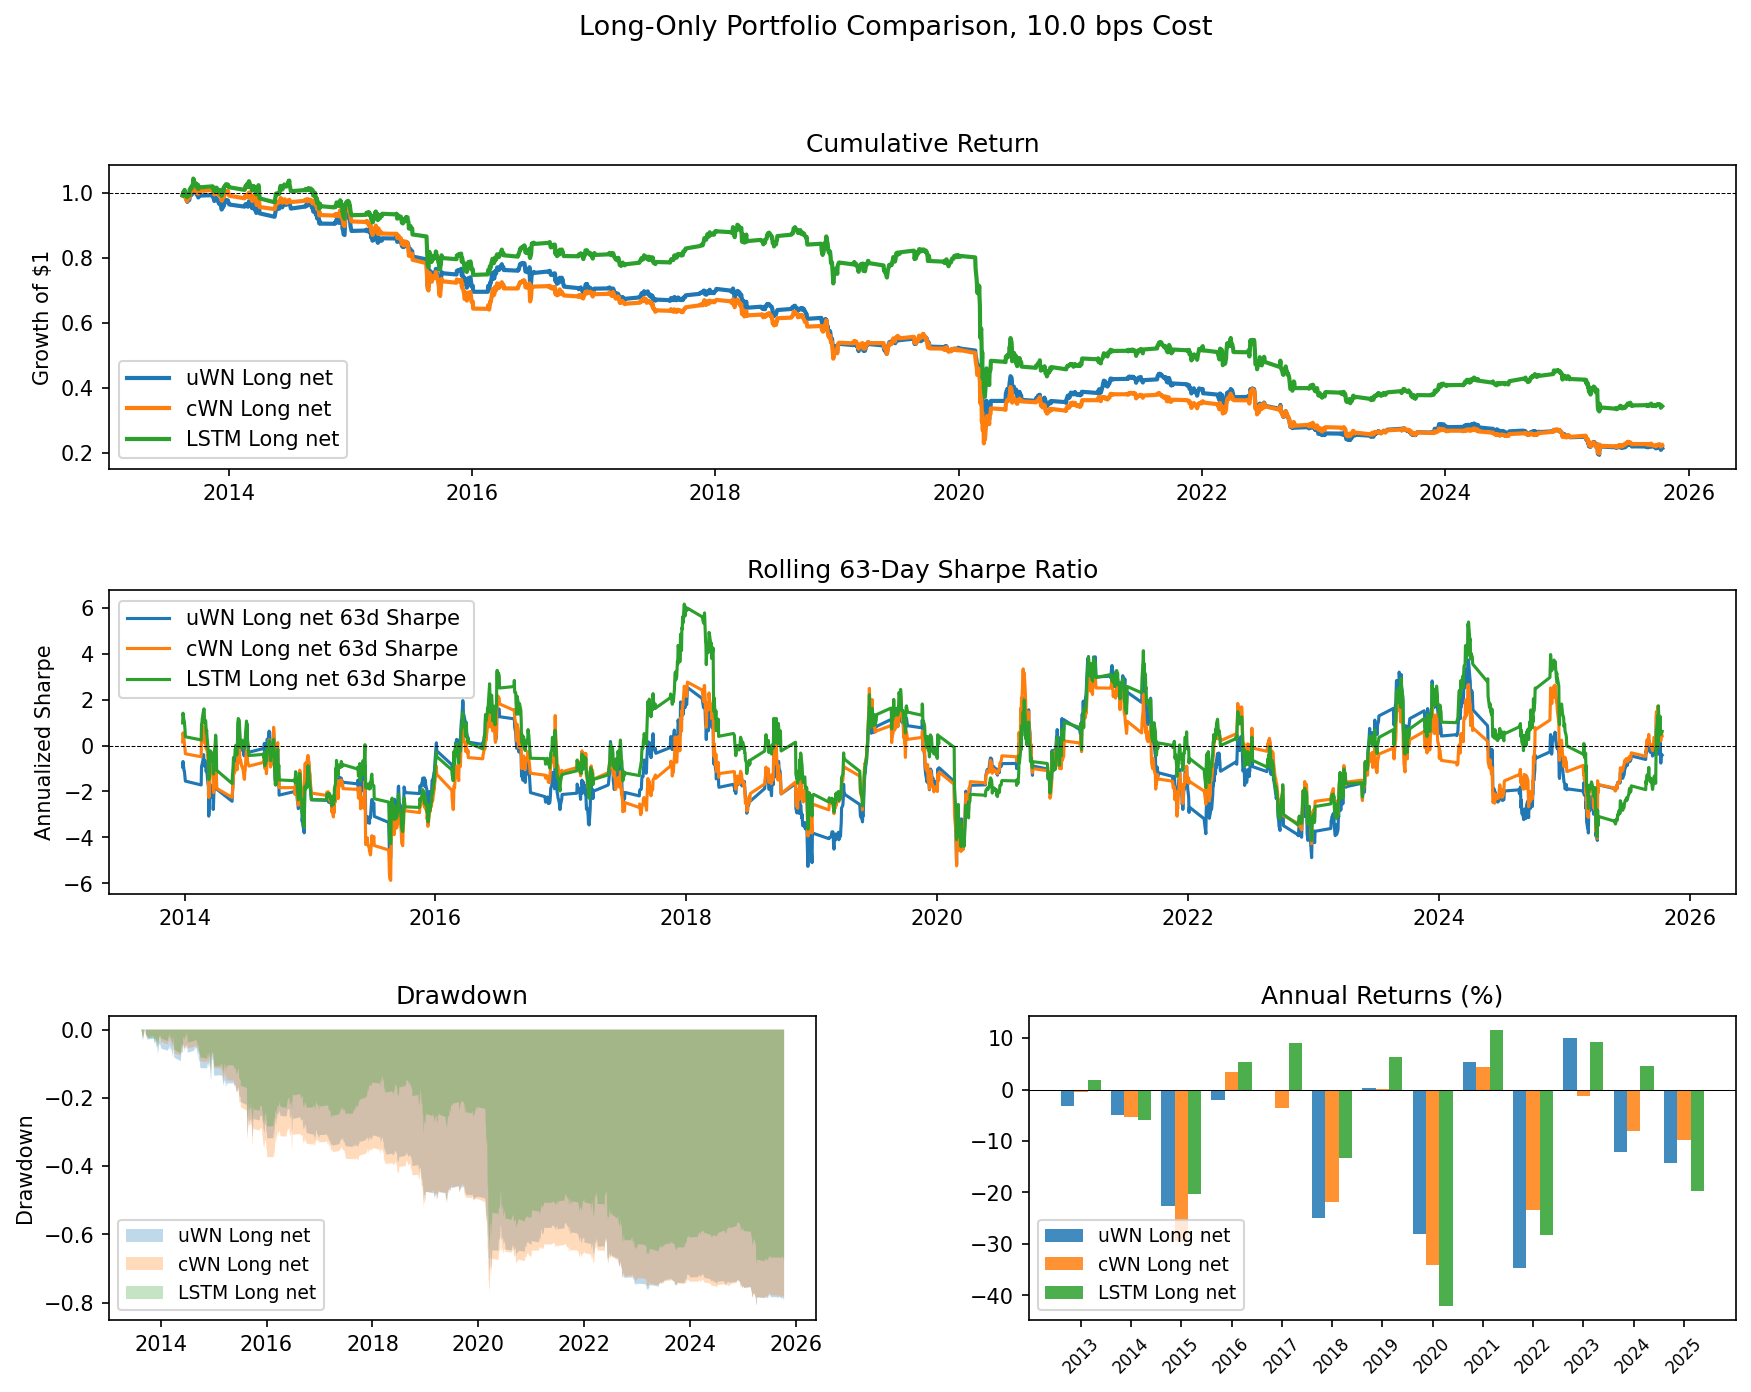

In [16]:
from IPython.display import Image, display

# Display transaction-cost-adjusted portfolio comparison plots.
display(Image(filename="transaction_cost/long_short_comparison.png"))
display(Image(filename="transaction_cost/long_only_comparison.png"))

The transaction cost module saves the following outputs:

```text
transaction_cost/
├── metrics.csv
├── daily_returns.csv
├── cumulative_returns.csv
├── long_short_comparison.png
└── long_only_comparison.png
```

The `metrics.csv` file compares the net long-short portfolio, gross long-short portfolio, and long-only portfolio for each model. The `daily_returns.csv` file stores strategy returns, turnover, and transaction cost information. The two plot files visualize the long-short and long-only cumulative performance separately.

The main interpretation from this extension is that portfolio performance should be evaluated under realistic trading assumptions. A strategy with strong gross returns may become much weaker once turnover costs are deducted. Therefore, this module allows the project to compare models not only by predictive accuracy or raw backtest returns, but also by implementable portfolio performance.


### Transaction Cost Result Interpretation

In this experiment, I use a daily rebalancing strategy with a 20% long-short rule. Each day, the strategy goes long the top 20% of stocks ranked by predicted return and short the bottom 20%. I assume a one-way transaction cost of 10 basis points. 

The results show that transaction costs have a very large effect on portfolio performance. After deducting transaction costs, all long-short strategies perform very poorly. The uWN L/S net portfolio has a cumulative return of -83.19% and a Sharpe ratio of -3.224. The cWN L/S net portfolio has a cumulative return of -79.44% and a Sharpe ratio of -2.440. The LSTM L/S net portfolio also declines substantially. The cumulative return plot shows a steady decline in all three net long-short strategies, indicating that daily turnover costs overwhelm the predictive signal. The long-only strategy is also not immune to transaction costs. Cumulative returns of uWN Long net falls to -78.45% and cWN Long net falls to -77.57%. LSTM Long net also becomes negative, with a cumulative return of -65.59%. 

Overall, the transaction cost analysis shows that the original strategy is highly sensitive to implementation assumptions. The models can generate useful gross signals, especially for cWN, but daily rebalancing with a 10 bps one-way transaction cost makes both the long-short and long-only net strategies unattractive. So it is better to increase the holding period, and some future work can be applying a stronger signal threshold before trading, or using portfolio optimization methods that explicitly penalize turnover.

## **6.** Streamlit Web App

To make the project easier to explore, I added a Streamlit web application. The entry point is `app.py`, and the individual dashboard pages are stored in the `./pages/` folder.

The web app contains four main pages:

1. `01_data_explorer.py`: displays dataset summary information, feature distributions, and ticker-level feature time series.
2. `02_backtest_results.py`: visualizes cumulative returns, rolling Sharpe ratios, drawdowns, annual returns, and performance metrics from the main backtest.
3. `03_regime_analysis.py`: shows strategy performance across different market regimes.
4. `04_run_simulation.py`: allows the user to interactively change portfolio rules, including long group size, short group size, holding period, transaction cost, and strategy type. This page uses pre-computed model predictions.

The app uses `st.session_state["results_dir"]` to pass the selected results folder across pages. This keeps the dashboard flexible because the user can switch between different result folders from the sidebar and immediately view the corresponding analysis.


In [ ]:
# Launch the Streamlit dashboard from the project root.
# Run this command in the terminal, not inside a normal Python script.

!streamlit run app.py

The Streamlit app turns the project from a static backtesting pipeline into an interactive research dashboard. 

The simulation page is especially useful for sensitivity analysis. It allows the user to test different transaction costs, holding periods, and portfolio construction rules directly on the saved prediction files. This makes the project more practical because it separates model training from portfolio implementation.